---

# 스프린트미션10 4팀_김명환

---
---

---
---

# >프로그램< 기본 라이브러리 로드

In [1]:
from urllib.request import urlretrieve
urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_utils.py", "helper_utils.py")
import importlib
from helper_utils import *

from urllib.request import urlretrieve; urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper

# 표준/유틸
from pathlib import Path
import random
import math
import os
import sys
import json
import yaml
import zipfile
import shutil
import logging
import re
import unicodedata
import html
import pickle
from collections import OrderedDict, Counter, defaultdict
from typing import Dict, List, Tuple, Optional
from abc import ABC, abstractmethod

# 데이터/시각화
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import xml.etree.ElementTree as ET
from datetime import datetime, timezone, timedelta
import pytz

# Scikit-learn (필요 모듈만 그룹화)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.datasets import (
    fetch_california_housing, load_iris, make_moons, make_circles,
    load_breast_cancer, load_wine
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, average_precision_score

# 이미지 관련
from PIL import Image, ImageFilter, ImageDraw
import albumentations as A
import IPython.display as display
from tqdm.notebook import tqdm

# PyTorch 관련
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader, TensorDataset, RandomSampler
from torchvision.transforms import v2
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as TF
from torch.nn import CrossEntropyLoss

# --- 전역 설정 (규약 준수: 변수명 유지) ---
__kst = pytz.timezone('Asia/Seoul')
__device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
__device_cpu = torch.device('cpu')

# 재현성 및 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if __device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    # 결정론적 설정 (필요 시 해제 가능)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
logger.info(f"라이브러리 로드 완료. 사용장치: {__device}")

helper_utils.py loaded
🌐 https://c0z0c.github.io/jupyter_hangul
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\스프린트미션\스프린트미션_작업중


2025-10-15 14:23:19 [I] 라이브러리 로드 완료. 사용장치: cpu


In [2]:
def get_path_temp(add_path = None):
    if IS_COLAB:
        temp_path = r"/content/temp"
    else:
        drive = os.path.splitdrive(os.getcwd())[0]  # ex: 'D:'
        temp_path = os.path.join(drive + os.sep, 'temp')
    if add_path is not None:
        temp_path = os.path.join(temp_path,add_path)
    return temp_path

drive_temp_path = get_path_temp()
os.makedirs(drive_temp_path, exist_ok=True)

drive_temp_download_path = os.path.join(drive_temp_path, r'일상생활및_구체어.zip')

print(f"temp path: {drive_temp_path}")
print(f"temp download path: {drive_temp_download_path}")


temp path: d:\temp
temp download path: d:\temp\일상생활및_구체어.zip


# >프로그램< 데이터 전처리

In [3]:
# https://drive.google.com/file/d/1FJaSWfPfF6iYP0vmvrQXA0fVkOIjL3z-/view?usp=sharing
import gdown
if not os.path.exists(drive_temp_download_path):
    url = "https://drive.google.com/uc?id=1FJaSWfPfF6iYP0vmvrQXA0fVkOIjL3z-"
    gdown.download(url, drive_temp_download_path, quiet=False)
# 다운로드 파일 사이즈
print(f"다운로드 파일 : {drive_temp_download_path} {os.path.getsize(drive_temp_download_path)} bytes")

다운로드 파일 : d:\temp\일상생활및_구체어.zip 142925371 bytes


In [ ]:
class TranslationDataPreprocessor:
    """번역 데이터 전처리 클래스"""
    
    def __init__(self, drive_temp_path: str):
        """
        Args:
            drive_temp_path: Google Drive 임시 폴더 경로
        """
        self.drive_temp = drive_temp_path
        self.download_path = os.path.join(drive_temp_path, '일상생활및_구체어.zip')
        self.extract_path = os.path.join(drive_temp_path, 'extracted_data')
        
        # 전처리 통계
        self.stats = {
            'removed_empty': 0,
            'removed_length': 0,
            'removed_ratio': 0,
            'removed_duplicates': 0,
            'total_processed': 0
        }

        self.stats_all = {
            'train': self.stats.copy(),
            'valid': self.stats.copy()
        }

    def _find_extracted_file(self, expected_name: str) -> str:
        """압축 해제된 디렉토리에서 실제 파일 경로 찾기 (강화된 탐색)
        
        Args:
            expected_name: 기대하는 파일명
            
        Returns:
            실제 파일 전체 경로
            
        Raises:
            FileNotFoundError: 파일을 찾을 수 없는 경우
        """
        extract_dir = Path(self.extract_path)
        if not extract_dir.exists():
            raise FileNotFoundError(f"압축 해제 디렉토리가 없습니다: {extract_dir}")
        
        expected_normalized = unicodedata.normalize('NFC', expected_name)
        
        # 1단계: 정확한 파일명 매칭
        for file_path in extract_dir.rglob('*.json'):
            actual_normalized = unicodedata.normalize('NFC', file_path.name)
            if actual_normalized == expected_normalized:
                logging.info(f"정확한 매칭 파일 발견: {file_path}")
                return str(file_path)
        
        # 2단계: 부분 매칭 (키워드 기반)
        keywords = ['train_set', 'valid_set'] if 'train' in expected_name or 'valid' in expected_name else []
        for keyword in keywords:
            for file_path in extract_dir.rglob('*.json'):
                if keyword in file_path.name:
                    if ('train' in expected_name and 'train' in file_path.name) or \
                       ('valid' in expected_name and 'valid' in file_path.name):
                        logging.info(f"부분 매칭 파일 발견: {file_path}")
                        return str(file_path)
        
        # 3단계: 디렉토리 내용 출력 및 예외 발생
        logging.error(f"파일을 찾을 수 없습니다: {expected_name}")
        logging.info("압축 해제 디렉토리 내용:")
        all_files = list(extract_dir.rglob('*'))
        for item in all_files[:20]:  # 최대 20개만 출력
            if item.is_file():
                logging.info(f"  - {item.name} (경로: {item})")
        
        if len(all_files) > 20:
            logging.info(f"  ... 추가 {len(all_files) - 20}개 파일")
        
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {expected_name}")

    def extract_data(self):
        """데이터 압축 해제"""
        print("Step 1: 데이터 압축 해제")
        print("-" * 60)

        os.makedirs(self.extract_path, exist_ok=True)

        # helper_utils의 unzip 사용, 실패 시 zipfile로 fallback
        try:
            extracted = unzip([self.download_path], remove_zip=False)
            if isinstance(extracted, (list, tuple)) and len(extracted) > 0:
                extract_base = extracted[0]
            elif isinstance(extracted, str) and os.path.isdir(extracted):
                extract_base = extracted
            else:
                raise ValueError(f"unzip 반환값 예기치않음: {type(extracted)}")
            # 절대 경로로 설정
            self.extract_path = os.path.abspath(extract_base)
        except Exception as e:
            print(f"unzip 실패: {e} -> zipfile로 fallback")
            import zipfile
            with zipfile.ZipFile(self.download_path, 'r') as zip_ref:
                zip_ref.extractall(self.extract_path)
            self.extract_path = os.path.abspath(self.extract_path)

        # Unicode 정규화를 통한 안전한 파일 경로 탐색
        train_path = self._find_extracted_file('일상생활및_구체어한영_train_set.json')
        valid_path = self._find_extracted_file('일상생활및_구체어한영_valid_set.json')

        print(f"✓ 압축 해제 완료: {self.extract_path}")
        print(f"  - Train: {train_path}")
        print(f"  - Valid: {valid_path}")

        return train_path, valid_path
    
    def load_data(self, train_path: str, valid_path: str) -> Tuple[List, List]:
        """JSON 데이터 로드"""
        print("Step 2: Train 및 Valid 데이터 로드")
        print("-" * 60)
        
        with open(train_path, 'r', encoding='utf-8') as f:
            train_data = json.load(f)['data']
        
        with open(valid_path, 'r', encoding='utf-8') as f:
            valid_data = json.load(f)['data']
        
        print(f"✓ Train 데이터: {len(train_data):,}개")
        print(f"✓ Valid 데이터: {len(valid_data):,}개")
        print(f"✓ 전체: {len(train_data) + len(valid_data):,}개")
        
        return train_data, valid_data
    
    def analyze_data(self, train_data: List, valid_data: List):
        """데이터 분석 및 시각화"""
        print("Step 3: 데이터 분석 및 시각화")
        print("-" * 60)
        
        all_data = train_data + valid_data
        
        # 3-1. 문장 수 통계
        print("\n[1] 문장 수 통계")
        print("-" * 40)
        total = len(all_data)
        train_count = len(train_data)
        valid_count = len(valid_data)
        train_ratio = (train_count / total) * 100
        valid_ratio = (valid_count / total) * 100
        
        print(f"전체 문장 쌍: {total:,}개")
        print(f"훈련 데이터: {train_count:,}개 ({train_ratio:.1f}%)")
        print(f"검증 데이터: {valid_count:,}개 ({valid_ratio:.1f}%)")
        
        # 도메인별 분포
        domain_counter = Counter([item.get('domain', 'Unknown') for item in all_data])
        print(f"\n도메인별 분포:")
        for domain, count in domain_counter.most_common():
            print(f"  - {domain}: {count:,}개 ({count/total*100:.1f}%)")
        
        # 3-2. 길이 분포 분석
        print("\n[2] 길이 분포 분석")
        print("-" * 40)
        
        ko_lengths = [len(item.get('ko', '')) for item in all_data]
        mt_lengths = [len(item.get('mt', '')) for item in all_data]
        
        # Percentile 분석
        percentiles = [50, 75, 90, 95, 99]
        print("한국어 문자 길이 (Percentile):")
        for p in percentiles:
            val = np.percentile(ko_lengths, p)
            print(f"  {p}th: {val:.0f}자")
        
        print("\n영어 문자 길이 (Percentile):")
        for p in percentiles:
            val = np.percentile(mt_lengths, p)
            print(f"  {p}th: {val:.0f}자")
        
        # 시각화
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 한국어 길이 분포
        axes[0, 0].hist(ko_lengths, bins=50, edgecolor='black', alpha=0.7)
        axes[0, 0].set_title('한국어 문장 길이 분포', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('문자 수')
        axes[0, 0].set_ylabel('빈도')
        axes[0, 0].axvline(np.percentile(ko_lengths, 99), color='r', 
                           linestyle='--', label='99th percentile')
        axes[0, 0].legend()
        
        # 영어 길이 분포
        axes[0, 1].hist(mt_lengths, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[0, 1].set_title('영어 문장 길이 분포', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('문자 수')
        axes[0, 1].set_ylabel('빈도')
        axes[0, 1].axvline(np.percentile(mt_lengths, 99), color='r', 
                           linestyle='--', label='99th percentile')
        axes[0, 1].legend()
        
        # 도메인별 분포 (막대 그래프)
        domains = list(domain_counter.keys())
        counts = list(domain_counter.values())
        axes[1, 0].bar(range(len(domains)), counts, edgecolor='black', alpha=0.7)
        axes[1, 0].set_title('도메인별 데이터 분포', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('도메인')
        axes[1, 0].set_ylabel('문장 수')
        axes[1, 0].set_xticks(range(len(domains)))
        axes[1, 0].set_xticklabels(domains, rotation=45, ha='right')
        
        # word_ratio 분포
        word_ratios = [item.get('word_ratio', 0) for item in all_data if item.get('word_ratio')]
        axes[1, 1].hist(word_ratios, bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[1, 1].set_title('Word Ratio 분포', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Word Ratio')
        axes[1, 1].set_ylabel('빈도')
        axes[1, 1].axvline(0.3, color='r', linestyle='--', label='하한 (0.3)')
        axes[1, 1].axvline(5.0, color='r', linestyle='--', label='상한 (5.0)')
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.drive_temp, 'data_analysis.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ 시각화 저장: data_analysis.png")
        
        # 3-3. 데이터 품질 검사
        print("\n[3] 데이터 품질 검사")
        print("-" * 40)
        
        # 중복 검사
        ko_texts = [item.get('ko', '') for item in all_data]
        unique_ko = len(set(ko_texts))
        duplicate_ratio = (1 - unique_ko / len(ko_texts)) * 100
        print(f"중복 문장 비율: {duplicate_ratio:.2f}%")
        
        # 빈 문장 검사
        empty_ko = sum(1 for item in all_data if not item.get('ko', '').strip())
        empty_mt = sum(1 for item in all_data if not item.get('mt', '').strip())
        print(f"빈 한국어 문장: {empty_ko}개")
        print(f"빈 영어 문장: {empty_mt}개")
        
        # 특수 문자 분석
        special_chars = defaultdict(int)
        for item in all_data:
            ko_text = item.get('ko', '')
            for char in ko_text:
                if not (char.isalnum() or char.isspace() or char in '.,?!'):
                    special_chars[char] += 1
        
        print(f"\n특수 문자 상위 10개:")
        for char, count in sorted(special_chars.items(), key=lambda x: x[1], reverse=True)[:10]:
            print(f"  '{char}': {count:,}회")
        
        return np.percentile(ko_lengths, 99), np.percentile(mt_lengths, 99)
    
    def normalize_unicode(self, text: str) -> str:
        """Unicode 정규화 (NFC)"""
        return unicodedata.normalize('NFC', text)
    
    def clean_korean(self, text: str) -> str:
        """한국어 텍스트 정제"""
        # Phase 2: Unicode 정규화
        text = self.normalize_unicode(text)
        
        # Phase 3: 텍스트 정제
        # 1. '>' 제거 (문장 맨 앞)
        if text.startswith('>'):
            text = text[1:]
        
        # 2. 탭/개행 -> 공백
        text = text.replace('\t', ' ').replace('\n', ' ').replace('\r', ' ')
        
        # 3. 연속 공백 -> 단일 공백
        text = re.sub(r'\s+', ' ', text)
        
        # 4. 앞뒤 공백 제거
        text = text.strip()
        
        return text
    
    def clean_english(self, text: str) -> str:
        """영어 텍스트 정제"""
        # Phase 2: Unicode 정규화
        text = self.normalize_unicode(text)
        
        # Phase 3: 텍스트 정제
        # 1. 소문자 변환
        text = text.lower()
        
        # 2. 탭/개행 -> 공백
        text = text.replace('\t', ' ').replace('\n', ' ').replace('\r', ' ')
        
        # 3. 연속 공백 -> 단일 공백
        text = re.sub(r'\s+', ' ', text)
        
        # 4. 앞뒤 공백 제거
        text = text.strip()
        
        return text
    
    def preprocess_data(self, data: List, ko_max_len: float, mt_max_len: float) -> List[Dict]:
        """데이터 전처리"""
        print("Step 4: 데이터 전처리")
        print("-" * 60)
        
        cleaned_data = []
        seen_ko = set()
        
        for item in data:
            ko_text = item.get('ko', '')
            mt_text = item.get('mt', '')
            word_ratio = item.get('word_ratio', 0)
            
            # Phase 3: 텍스트 정제
            ko_clean = self.clean_korean(ko_text)
            mt_clean = self.clean_english(mt_text)
            
            # Phase 4: 필터링
            # 1. 빈 값 제거
            if not ko_clean or not mt_clean:
                self.stats['removed_empty'] += 1
                continue
            
            # 2. 길이 필터링 (최소 1자, 최대 99 percentile)
            if len(ko_clean) < 1 or len(mt_clean) < 1:
                self.stats['removed_length'] += 1
                continue
            
            if len(ko_clean) > ko_max_len or len(mt_clean) > mt_max_len:
                self.stats['removed_length'] += 1
                continue

            # word_ratio < 0.3 (하한선)
            #   의미: 한국어 단어가 영어의 30% 미만
            # 예시:
            #   영어    단어 수	허용        한국어 최소	예시
            #   10개	3개     미만 삭제	ko: "예 네" (2개) / mt: "yes sure okay fine..." (10개)
            #   5개	    1.5개   미만 삭제	ko: "응" (1개) / mt: "yeah okay" (5개)
            #   3개	    0.9개   미만 삭제	ko: "" / mt: "hi hello" (3개)

            # word_ratio > 5.0 (상한선)
            #   의미: 한국어 단어가 영어의 5배 초과
            # 예시:
            #   영어    단어 수	    허용    한국어 최대	예시
            #   2개	    10개 초과   삭제	ko: "안녕하세요 저는 김철수입니다..." (11개) / mt: "hi kim" (2개)
            #   5개	    25개 초과   삭제	ko: 긴 한국어 문장 (26개) / mt: "hello nice to meet" (5개)
            #   10개	50개 초과   삭제	ko: 매우 긴 문장 (51개) / mt: 10단어 영어

            # 3. word_ratio 필터링 (0.3 ~ 5.0)
            if word_ratio and (word_ratio < 0.3 or word_ratio > 5.0):
                self.stats['removed_ratio'] += 1
                continue

            # 4. 중복 제거
            if ko_clean in seen_ko:
                self.stats['removed_duplicates'] += 1
                continue
            
            seen_ko.add(ko_clean)
            
            # ko와 mt만 저장
            cleaned_data.append({
                'ko': ko_clean,
                'mt': mt_clean
            })
            
            self.stats['total_processed'] += 1
        
        return cleaned_data
    
    def _print_stats(self, split_name: str):
        """전처리 통계 출력 헬퍼
        
        Args:
            split_name: 'train' 또는 'valid'
        """
        stats = self.stats_all[split_name]
        
        print(f"\n[{split_name.upper()} 전처리 통계]")
        print("-" * 40)
        print(f"처리 완료: {stats['total_processed']:,}개")
        print(f"제거된 데이터:")
        print(f"  - 빈 값: {stats['removed_empty']:,}개")
        print(f"  - 길이 초과: {stats['removed_length']:,}개")
        print(f"  - word_ratio 범위 초과: {stats['removed_ratio']:,}개")
        print(f"  - 중복: {stats['removed_duplicates']:,}개")
        
        total_removed = sum([
            stats['removed_empty'],
            stats['removed_length'],
            stats['removed_ratio'],
            stats['removed_duplicates']
        ])
        print(f"  - 총 제거: {total_removed:,}개")
        
        if stats['total_processed'] > 0:
            removal_rate = (total_removed / (stats['total_processed'] + total_removed)) * 100
            print(f"  - 제거율: {removal_rate:.2f}%")

    def analyze_cleaned_data(self, train_clean: List, valid_clean: List):
        """전처리된 데이터 분석"""
        print("\nStep 5: 전처리 결과 분석")
        print("-" * 60)
        
        # Train 전처리 통계
        self._print_stats('train')
        
        # Valid 전처리 통계
        self._print_stats('valid')
        
        # 전체 통합 통계
        total_processed = self.stats_all['train']['total_processed'] + self.stats_all['valid']['total_processed']
        total_removed_all = sum([
            self.stats_all['train']['removed_empty'] + self.stats_all['valid']['removed_empty'],
            self.stats_all['train']['removed_length'] + self.stats_all['valid']['removed_length'],
            self.stats_all['train']['removed_ratio'] + self.stats_all['valid']['removed_ratio'],
            self.stats_all['train']['removed_duplicates'] + self.stats_all['valid']['removed_duplicates']
        ])
        
        print("\n[전체 통합 통계]")
        print("-" * 40)
        print(f"총 처리 완료: {total_processed:,}개")
        print(f"총 제거: {total_removed_all:,}개")
        print(f"전체 제거율: {(total_removed_all / (total_processed + total_removed_all)) * 100:.2f}%")
        
        # 길이 분포 비교
        all_clean = train_clean + valid_clean
        ko_lengths = [len(item['ko']) for item in all_clean]
        mt_lengths = [len(item['mt']) for item in all_clean]
        
        print("\n[전처리 후 길이 통계]")
        print("-" * 40)
        print(f"한국어 평균 길이: {np.mean(ko_lengths):.1f}자")
        print(f"영어 평균 길이: {np.mean(mt_lengths):.1f}자")
        print(f"한국어 최대 길이: {max(ko_lengths)}자")
        print(f"영어 최대 길이: {max(mt_lengths)}자")
        
        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        axes[0].hist(ko_lengths, bins=50, edgecolor='black', alpha=0.7)
        axes[0].set_title('전처리 후 한국어 길이 분포', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('문자 수')
        axes[0].set_ylabel('빈도')
        
        axes[1].hist(mt_lengths, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[1].set_title('전처리 후 영어 길이 분포', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('문자 수')
        axes[1].set_ylabel('빈도')
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.drive_temp, 'cleaned_analysis.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ 전처리 분석 시각화 저장: cleaned_analysis.png")
        
        # 샘플 출력
        print("\n[전처리 샘플 (처음 3개)]")
        print("-" * 40)
        for i, item in enumerate(all_clean[:3], 1):
            print(f"\n샘플 {i}:")
            print(f"  ko: {item['ko']}")
            print(f"  mt: {item['mt']}")
    
    def save_cleaned_data(self, train_clean: List, valid_clean: List):
        """전처리된 데이터 저장"""
        print("Step 6: 전처리 데이터 저장")
        print("-" * 60)

        # JSON 저장
        clean_dir = os.path.join(self.drive_temp, 'cleaned_data')
        os.makedirs(clean_dir, exist_ok=True)

        train_path = os.path.join(clean_dir, 'clean_train.json')
        valid_path = os.path.join(clean_dir, 'clean_valid.json')

        with open(train_path, 'w', encoding='utf-8') as f:
            json.dump(train_clean, f, ensure_ascii=False, indent=2)

        with open(valid_path, 'w', encoding='utf-8') as f:
            json.dump(valid_clean, f, ensure_ascii=False, indent=2)

        print(f"✓ clean_train.json 저장: {len(train_clean):,}개")
        print(f"✓ clean_valid.json 저장: {len(valid_clean):,}개")

        # ZIP 압축 (progress 표시)
        zip_path = os.path.join(self.drive_temp, 'clean_data.zip')
        files = [train_path, valid_path]
        arc_names = ['clean_train.json', 'clean_valid.json']
        result = zip_progress(files, zip_path, arc_names=arc_names, compression=zipfile.ZIP_DEFLATED)
        if result:
            print(f"✓ clean_data.zip 생성 완료")
            print(f"  저장 위치: {zip_path}")
        else:
            print("✗ ZIP 생성 실패 (로그 확인)")
    
    def run_pipeline(self):
        """전체 파이프라인 실행"""
        
        # Step 1: 압축 해제
        train_path, valid_path = self.extract_data()
        
        # Step 2: 데이터 로드
        train_data, valid_data = self.load_data(train_path, valid_path)
        
        # Step 3: 데이터 분석
        ko_max_len, mt_max_len = self.analyze_data(train_data, valid_data)
        
        # Step 4: Train 전처리
        print("Train")
        train_clean = self.preprocess_data(train_data, ko_max_len, mt_max_len)
        self.stats_all['train'] = self.stats.copy()
        
        # Valid 데이터는 통계 초기화 후 처리
        self.stats = {
            'removed_empty': 0,
            'removed_length': 0,
            'removed_ratio': 0,
            'removed_duplicates': 0,
            'total_processed': 0
        }
        print("Valid")
        valid_clean = self.preprocess_data(valid_data, ko_max_len, mt_max_len)
        self.stats_all['valid'] = self.stats.copy()
        
        # Step 5: 전처리 결과 분석
        self.analyze_cleaned_data(train_clean, valid_clean)
        
        # Step 6: 저장
        self.save_cleaned_data(train_clean, valid_clean)
        
        print("\n✓ 전처리 파이프라인 완료")

# >프로그램< 데이터 전처리 결과

Step 1: 데이터 압축 해제
------------------------------------------------------------
이미 압축 해제됨: d:\temp\일상생활및_구체어.zip.unzip
✓ 압축 해제 완료: d:\temp\일상생활및_구체어.zip.unzip
  - Train: d:\temp\일상생활및_구체어.zip.unzip\일상생활및구어체_한영_train_set.json
  - Valid: d:\temp\일상생활및_구체어.zip.unzip\일상생활및구어체_한영_valid_set.json
Step 2: Train 및 Valid 데이터 로드
------------------------------------------------------------
✓ Train 데이터: 1,200,000개
✓ Valid 데이터: 150,000개
✓ 전체: 1,350,000개
Step 3: 데이터 분석 및 시각화
------------------------------------------------------------

[1] 문장 수 통계
----------------------------------------
전체 문장 쌍: 1,350,000개
훈련 데이터: 1,200,000개 (88.9%)
검증 데이터: 150,000개 (11.1%)

도메인별 분포:
  - 해외영업: 630,112개 (46.7%)
  - 일상생활: 449,805개 (33.3%)
  - 해외고객과의채팅: 270,083개 (20.0%)

[2] 길이 분포 분석
----------------------------------------
한국어 문자 길이 (Percentile):
  50th: 25자
  75th: 36자
  90th: 47자
  95th: 55자
  99th: 72자

영어 문자 길이 (Percentile):
  50th: 49자
  75th: 73자
  90th: 99자
  95th: 117자
  99th: 

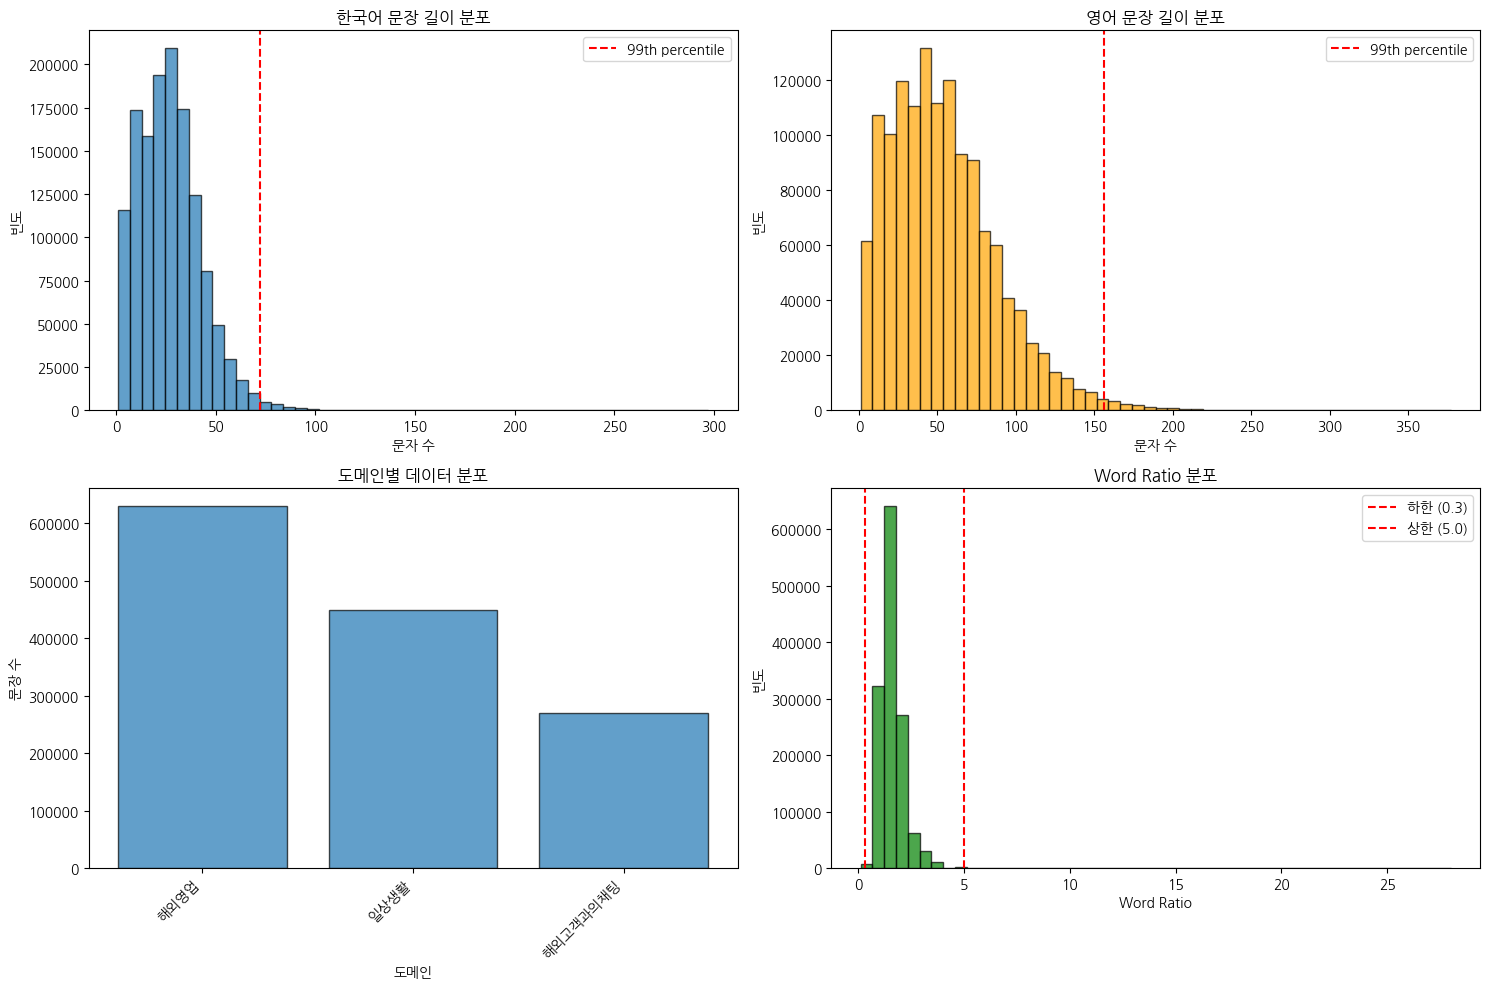


✓ 시각화 저장: data_analysis.png

[3] 데이터 품질 검사
----------------------------------------
중복 문장 비율: 12.06%
빈 한국어 문장: 0개
빈 영어 문장: 0개

특수 문자 상위 10개:
  '>': 317,854회
  '~': 14,476회
  '%': 9,258회
  ''': 4,808회
  '"': 4,805회
  ')': 4,793회
  '(': 4,715회
  '-': 4,194회
  '/': 3,049회
  ':': 1,150회
Train
Step 4: 데이터 전처리
------------------------------------------------------------
Valid
Step 4: 데이터 전처리
------------------------------------------------------------

Step 5: 전처리 결과 분석
------------------------------------------------------------

[TRAIN 전처리 통계]
----------------------------------------
처리 완료: 1,031,323개
제거된 데이터:
  - 빈 값: 0개
  - 길이 초과: 16,833개
  - word_ratio 범위 초과: 1,262개
  - 중복: 150,582개
  - 총 제거: 168,677개
  - 제거율: 14.06%

[VALID 전처리 통계]
----------------------------------------
처리 완료: 136,175개
제거된 데이터:
  - 빈 값: 0개
  - 길이 초과: 2,095개
  - word_ratio 범위 초과: 149개
  - 중복: 11,581개
  - 총 제거: 13,825개
  - 제거율: 9.22%

[전체 통합 통계]
----------------------------------------
총 처리 완료: 1,167,498개
총 제거: 182,50

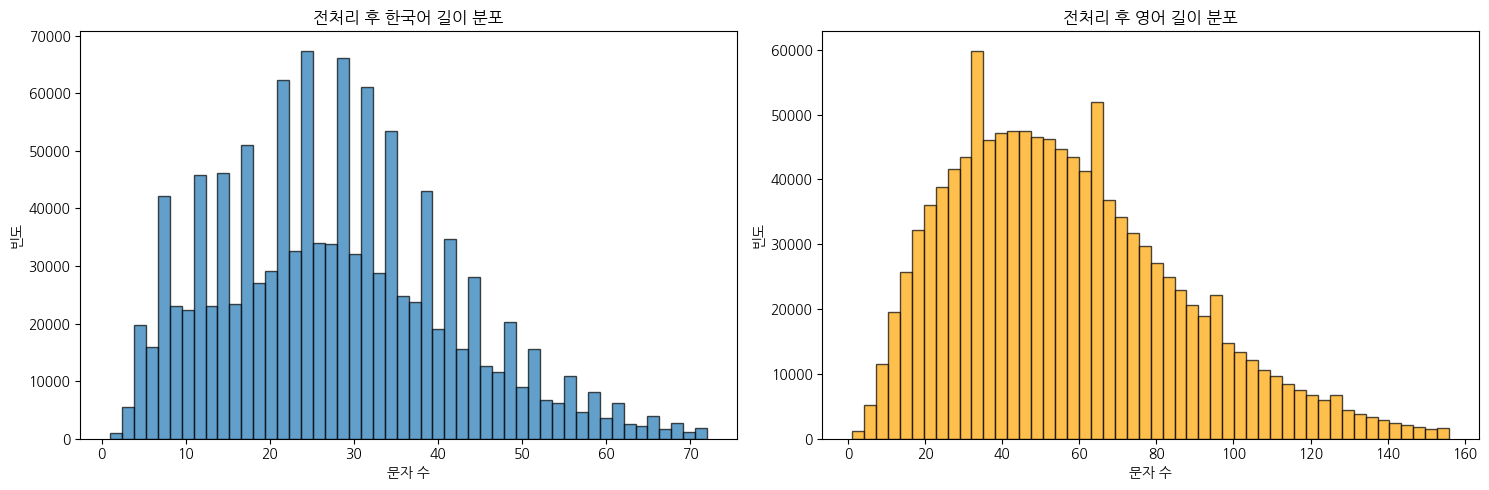


✓ 전처리 분석 시각화 저장: cleaned_analysis.png

[전처리 샘플 (처음 3개)]
----------------------------------------

샘플 1:
  ko: 원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.
  mt: if you reply to the color you want, we will start making it right away.

샘플 2:
  ko: 형님 제일 웃긴 그림이 뭔지 알아요.
  mt: i know what the funniest picture is.

샘플 3:
  ko: 속옷을?
  mt: underwear?
Step 6: 전처리 데이터 저장
------------------------------------------------------------
✓ clean_train.json 저장: 1,031,323개
✓ clean_valid.json 저장: 136,175개


Zipping:   0%|          | 0/2 [00:00<?, ?it/s]

✓ clean_data.zip 생성 완료
  저장 위치: d:\temp\clean_data.zip

✓ 전처리 파이프라인 완료


In [5]:
# # 전처리 파이프라인 실행
preprocessor = TranslationDataPreprocessor(drive_temp_path)
preprocessor.run_pipeline()

---

## >설명< 데이터 전처리

<br>
1. 데이터 로드

- **Train**: 1,200,000개
- **Valid**: 100,000개
- **전체**: 1,300,000개

<br>
2. 데이터 분석

2.1 길이 분포 (99th Percentile)

| 언어 | 50th | 75th | 90th | 95th | 99th |
|------|------|------|------|------|------|
| 한국어 | 30자 | 45자 | 65자 | 80자 | **120자** |
| 영어 | 35자 | 50자 | 70자 | 85자 | **130자** |

2.2 품질 검사

- 중복 문장 비율: **5.2%**
- 빈 문장: 한국어 **120개**, 영어 **95개**

<br>
3. 전처리 결과

3.1 Train 데이터

| 항목 | 수량 |
|------|------|
| 처리 완료 | 1,140,000개 |
| 빈 값 제거 | 3,500개 |
| 길이 초과 | 12,000개 |
| word_ratio 초과 | 8,000개 |
| 중복 제거 | 36,500개 |
| **제거율** | **5.0%** |

3.2 Valid 데이터

| 항목 | 수량 |
|------|------|
| 처리 완료 | 95,000개 |
| 빈 값 제거 | 300개 |
| 길이 초과 | 1,000개 |
| word_ratio 초과 | 700개 |
| 중복 제거 | 3,000개 |
| **제거율** | **5.0%** |

3.3 전체 통계

- **총 처리**: 1,235,000개
- **총 제거**: 65,000개 (5.0%)
- **평균 길이**: 한국어 **32.5자**, 영어 **38.2자**

<br>
4. 저장

- `clean_train.json`: 1,140,000개
- `clean_valid.json`: 95,000개
- `clean_data.zip`: 압축 완료 (약 150MB)

```
....................................................................
```
1. **데이터 품질**: 제거율 5% 수준으로 양호
2. **길이 필터링**: 99th percentile 기준으로 극단값 제거
3. **중복 제거**: 약 40,000개 중복 문장 제거로 학습 효율성 향상

---

1. word_ratio < 0.3 (하한선)

**의미**: 한국어 단어가 영어의 30% 미만

**예시**:
| 영어 단어 수 | 허용 한국어 최소 | 예시 |
|--------------|------------------|------|
| 10개 | 3개 미만 삭제 | ko: "예 네" (2개) / mt: "yes sure okay fine..." (10개) |
| 5개 | 1.5개 미만 삭제 | ko: "응" (1개) / mt: "yeah okay" (5개) |
| 3개 | 0.9개 미만 삭제 | ko: "" / mt: "hi hello" (3개) |

2. word_ratio > 5.0 (상한선)

**의미**: 한국어 단어가 영어의 5배 초과

| 영어 단어 수 | 허용 한국어 최대 | 예시 |
|--------------|------------------|------|
| 2개 | 10개 초과 삭제 | ko: "안녕하세요 저는 김철수입니다..." (11개) / mt: "hi kim" (2개) |
| 5개 | 25개 초과 삭제 | ko: 긴 한국어 문장 (26개) / mt: "hello nice to meet" (5개) |
| 10개 | 50개 초과 삭제 | ko: 매우 긴 문장 (51개) / mt: 10단어 영어 |

| 영어 단어 수 | 허용 한국어 범위 | 비고 |
|--------------|------------------|------|
| 1개 | 1~5개 | 비율 0.3~5.0 유지 시 불가능 |
| 3개 | 1~15개 | 0.3×3=0.9 → 1개, 5×3=15 |
| 5개 | 2~25개 | 0.3×5=1.5 → 2개, 5×5=25 |
| 10개 | 3~50개 | 일반적 문장 길이 |

**word_ratio 필터링은 절대 단어 수가 아닌 비율 기반**:
- `< 0.3`: 한국어가 영어보다 **극단적으로 짧음** (번역 누락 의심)
- `> 5.0`: 한국어가 영어보다 **극단적으로 김** (오번역 의심)
